In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

MASTER_CSV = "/content/drive/MyDrive/master_labels.csv"
SPLIT_CSV = "/content/drive/MyDrive/cholec80_master_split.csv"

df = pd.read_csv(SPLIT_CSV )

print(df.shape)
df.head()

(40357, 13)


,video_id,Frame,Grasper,Bipolar,Hook,Scissors,Clipper,Irrigator,SpecimenBag,Phase,time_sec,image_path,split
0,video01,0,1,0,0,0,0,0,0,Preparation,0.0,/content/data/cholec80_subset/frames_1fps/vide...,test
1,video01,25,1,0,0,0,0,0,0,Preparation,1.0,/content/data/cholec80_subset/frames_1fps/vide...,test
2,video01,50,1,0,0,0,0,0,0,Preparation,2.0,/content/data/cholec80_subset/frames_1fps/vide...,test
3,video01,75,1,0,0,0,0,0,0,Preparation,3.0,/content/data/cholec80_subset/frames_1fps/vide...,test
4,video01,100,0,0,0,0,0,0,0,Preparation,4.0,/content/data/cholec80_subset/frames_1fps/vide...,test


In [ ]:
# The CSV still has the old local-session path baked in — remap to where the
# images actually live now (Drive), since that old local folder no longer exists.
df['image_path'] = df['image_path'].str.replace(
    '/content/data/cholec80_subset/frames_1fps',
    '/content/drive/MyDrive/cholec80_frames',
    regex=False
)

# sanity check: confirm the new paths actually resolve
import os
df['image_exists'] = df['image_path'].apply(os.path.exists)
print(df['image_exists'].value_counts())
df = df.drop(columns='image_exists')

image_exists
True    40357
Name: count, dtype: int64


In [ ]:
df

,video_id,Frame,Grasper,Bipolar,Hook,Scissors,Clipper,Irrigator,SpecimenBag,Phase,time_sec,image_path,split
0,video01,0,1,0,0,0,0,0,0,Preparation,0.0,/content/drive/MyDrive/cholec80_frames/video01...,test
1,video01,25,1,0,0,0,0,0,0,Preparation,1.0,/content/drive/MyDrive/cholec80_frames/video01...,test
2,video01,50,1,0,0,0,0,0,0,Preparation,2.0,/content/drive/MyDrive/cholec80_frames/video01...,test
3,video01,75,1,0,0,0,0,0,0,Preparation,3.0,/content/drive/MyDrive/cholec80_frames/video01...,test
4,video01,100,0,0,0,0,0,0,0,Preparation,4.0,/content/drive/MyDrive/cholec80_frames/video01...,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40352,video46,41200,0,0,0,0,0,0,0,GallbladderRetraction,1648.0,/content/drive/MyDrive/cholec80_frames/video46...,train
40353,video46,41225,0,0,0,0,0,0,0,GallbladderRetraction,1649.0,/content/drive/MyDrive/cholec80_frames/video46...,train
40354,video46,41250,0,0,0,0,0,0,0,GallbladderRetraction,1650.0,/content/drive/MyDrive/cholec80_frames/video46...,train
40355,video46,41275,0,0,0,0,0,0,0,GallbladderRetraction,1651.0,/content/drive/MyDrive/cholec80_frames/video46...,train


In [ ]:

print(df["split"].value_counts())
print()
print("Train videos:", sorted(df[df['split']=='train']['video_id'].unique()))
print("Val videos:", sorted(df[df['split']=='val']['video_id'].unique()))
print("Test videos:", sorted(df[df['split']=='test']['video_id'].unique()))

split
train    29926
test      6524
val       3907
Name: count, dtype: int64

Train videos: ['video06', 'video11', 'video26', 'video31', 'video36', 'video41', 'video46', 'video51', 'video61', 'video66', 'video71']
Val videos: ['video21', 'video76']
Test videos: ['video01', 'video16', 'video56']


In [ ]:
!pip install lightly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.0 MB/s eta 0:00:00


In [ ]:
import copy
import torch
import torchvision
from PIL import Image
from torch.utils.data import Dataset, DataLoader

import copy

import pytorch_lightning as pl
import torch
import torchvision
from torch import nn

from lightly.loss import DINOLoss
from lightly.models.modules import DINOProjectionHead
from lightly.models.utils import deactivate_requires_grad, update_momentum
from lightly.transforms.dino_transform import DINOTransform
from lightly.utils.scheduler import cosine_schedule

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
class UnlabeledFrameDataset(Dataset):
    def __init__(self, dataframe, split='train', transform=None):
        self.image_paths = dataframe[dataframe['split'] == split]['image_path'].dropna().tolist()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img

example of the dinotransform ( crops ) for me :)

In [ ]:
#Dinotransform --> the crops
transform = DINOTransform()
# wanna see the difference

sample_path = df[df['split'] == 'train']['image_path'].dropna().iloc[0]
original_img = Image.open(sample_path).convert('RGB')
views = transform(original_img)

print(f"Number of views produced: {len(views)}")
for i, v in enumerate(views):
    print(f"View {i}: shape {v.shape}")


Number of views produced: 8
View 0: shape torch.Size([3, 224, 224])
View 1: shape torch.Size([3, 224, 224])
View 2: shape torch.Size([3, 96, 96])
View 3: shape torch.Size([3, 96, 96])
View 4: shape torch.Size([3, 96, 96])
View 5: shape torch.Size([3, 96, 96])
View 6: shape torch.Size([3, 96, 96])
View 7: shape torch.Size([3, 96, 96])


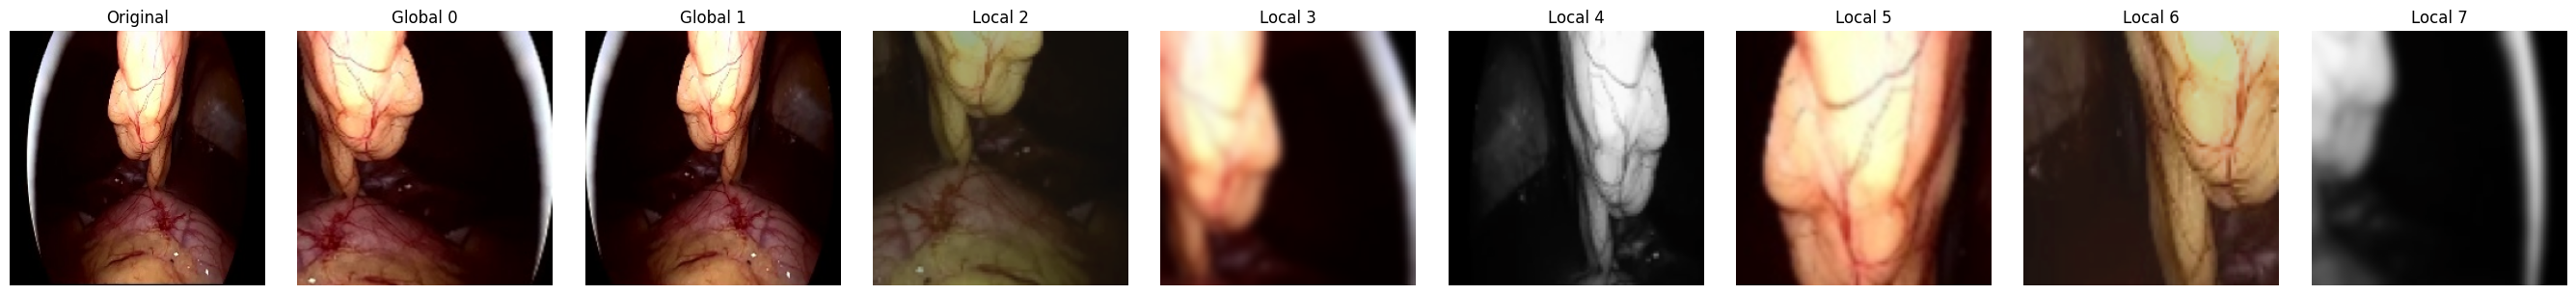

In [ ]:
# helper to convert a normalized tensor back to a displayable image
import torch
import matplotlib.pyplot as plt
# 8 views is the default #

def tensor_to_img(t):
    # undo normalization (DINOTransform uses ImageNet mean/std by default)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    t = t * std + mean
    t = t.clamp(0, 1)
    return t.permute(1, 2, 0).numpy()

n_views = len(views)
fig, axes = plt.subplots(1, n_views + 1, figsize=(3*(n_views+1), 3))

axes[0].imshow(original_img)
axes[0].set_title("Original")
axes[0].axis('off')

for i, v in enumerate(views):
    axes[i+1].imshow(tensor_to_img(v))
    label = "Global" if i < 2 else "Local"
    axes[i+1].set_title(f"{label} {i}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()


Reading images directly from Google Drive is very slow in Colab..

In [ ]:
# Copy frames from Drive to local Colab disk (Drive reads are slow, local disk is fast)
import shutil
import os

LOCAL_FRAMES_DIR = '/content/local_frames'

if not os.path.exists(LOCAL_FRAMES_DIR):
    print("Copying frames from Drive to local disk,")
    shutil.copytree('/content/drive/MyDrive/cholec80_frames', LOCAL_FRAMES_DIR)
    print("Done copying.")
else:
    print("Local frames already present, skipping copy.")


Copying frames from Drive to local disk,
Done copying.


In [ ]:
# Point image_path to the local copy instead of Drive, so DataLoader reads fast local files
df['image_path'] = df['image_path'].str.replace(
    '/content/drive/MyDrive/cholec80_frames',
    '/content/local_frames',
    regex=False
)

df['image_exists'] = df['image_path'].apply(os.path.exists)
print(df['image_exists'].value_counts())
df = df.drop(columns='image_exists')


image_exists
True    40357
Name: count, dtype: int64


In [ ]:
transform = DINOTransform()

train_dataset = UnlabeledFrameDataset(df, split='train', transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    drop_last=True,
)

print(f"Training on {len(train_dataset)} unlabeled frames")

Training on 29926 unlabeled frames


In [ ]:
NUM_EPOCHS = 5

class DINO(pl.LightningModule):
    def __init__(self, num_epochs):
        super().__init__()
        self.num_epochs = num_epochs

        resnet = torchvision.models.resnet18()
        backbone = nn.Sequential(*list(resnet.children())[:-1])# not the last layer
        input_dim = 512  # resnet18's feature size (resnet50 would be 2048)

        self.student_backbone = backbone
        #freezes the student head's very last layer for its first epoch of training,
        #since gradients tend to be noisiest right at the start, before the network has learned anything meaningful.
        #DINO projection head -->MLP network for DIno
        self.student_head = DINOProjectionHead(
            input_dim, 512, 64, 2048, freeze_last_layer=1
        )

        self.teacher_backbone = copy.deepcopy(backbone)
        self.teacher_head = DINOProjectionHead(input_dim, 512, 64, 2048)
        # teacher does not need the gradient update stuff
        deactivate_requires_grad(self.teacher_backbone)
        deactivate_requires_grad(self.teacher_head)
# logloss ish
        self.criterion = DINOLoss(output_dim=2048, warmup_teacher_temp_epochs=5) # smaller temp is like more confident and higher is less

    def forward(self, x):
        y = self.student_backbone(x).flatten(start_dim=1) # keeping batch dim
        z = self.student_head(y) # tranform to 2048
        return z

    def forward_teacher(self, x):
        y = self.teacher_backbone(x).flatten(start_dim=1) # keeping batch dim
        z = self.teacher_head(y) # tranform to 2048
        return z

    def training_step(self, batch, batch_idx):
        # momentum increases toward 1.0 over training (student leads, teacher trails)
        momentum = cosine_schedule(self.current_epoch, self.num_epochs, 0.996, 1)
        update_momentum(self.student_backbone, self.teacher_backbone, m=momentum)
        update_momentum(self.student_head, self.teacher_head, m=momentum)

        views = [view.to(self.device) for view in batch]
        global_views = views[:2]  # teacher only ever sees global crops

        teacher_out = [self.forward_teacher(view) for view in global_views]
        student_out = [self.forward(view) for view in views]  # student sees all crops

        loss = self.criterion(teacher_out, student_out, epoch=self.current_epoch)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_after_backward(self):
        # cancel gradients on the head's last layer during the freeze period
        self.student_head.cancel_last_layer_gradients(current_epoch=self.current_epoch)

    def configure_optimizers(self):
        optim = torch.optim.Adam(self.parameters(), lr=0.001)
        return optim


In [ ]:
model = DINO(num_epochs=NUM_EPOCHS)

trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="gpu",
    devices=1,
    default_root_dir="/content/drive/MyDrive/dino_checkpoints",
)

/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model, train_loader)

Epoch 4/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1870/1870 0:08:33 • 0:00:00 3.63it/s v_num: 4.000 train_loss: 7.082

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:

import torch

BACKBONE_SAVE_PATH = "/content/drive/MyDrive/dino_teacher_backbone_final.pth"

torch.save(model.teacher_backbone.state_dict(), BACKBONE_SAVE_PATH)
print(f"Final SSL backbone saved to: {BACKBONE_SAVE_PATH}")


Final SSL backbone saved to: /content/drive/MyDrive/dino_teacher_backbone_final.pth


### Setup: imports, backbone loading, labeled dataset

In [ ]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score

TOOL_COLS = ['Grasper', 'Bipolar', 'Hook', 'Scissors', 'Clipper', 'Irrigator', 'SpecimenBag']

# encode phase labels as integers
phase_names = sorted(df['Phase'].unique())
phase_to_idx = {p: i for i, p in enumerate(phase_names)}
idx_to_phase = {i: p for p, i in phase_to_idx.items()}
df['phase_idx'] = df['Phase'].map(phase_to_idx)

print("Phases:", phase_to_idx)


Phases: {'CalotTriangleDissection': 0, 'CleaningCoagulation': 1, 'ClippingCutting': 2, 'GallbladderDissection': 3, 'GallbladderPackaging': 4, 'GallbladderRetraction': 5, 'Preparation': 6}


In [ ]:
class LabeledFrameDataset(Dataset):
    """Loads images + phase label + tool labels. Used for classifier probing and LoRA."""

    def __init__(self, dataframe, split='train', transform=None):
        self.df = dataframe[dataframe['split'] == split].dropna(subset=['image_path']).reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        phase_label = torch.tensor(row['phase_idx'], dtype=torch.long)
        tool_labels = torch.tensor(row[TOOL_COLS].values.astype(np.float32))

        return img, phase_label, tool_labels


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_labeled_dataset = LabeledFrameDataset(df, split='train', transform=eval_transform)
val_labeled_dataset   = LabeledFrameDataset(df, split='val', transform=eval_transform)
test_labeled_dataset  = LabeledFrameDataset(df, split='test', transform=eval_transform)

train_labeled_loader = DataLoader(train_labeled_dataset, batch_size=64, shuffle=True, num_workers=2)
val_labeled_loader   = DataLoader(val_labeled_dataset, batch_size=64, shuffle=False, num_workers=2)
test_labeled_loader  = DataLoader(test_labeled_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_labeled_dataset)}, Val: {len(val_labeled_dataset)}, Test: {len(test_labeled_dataset)}")


Train: 29926, Val: 3907, Test: 6524


In [ ]:
def load_dino_backbone(checkpoint_path):
    resnet = torchvision.models.resnet18()
    backbone = nn.Sequential(*list(resnet.children())[:-1])
    backbone.load_state_dict(torch.load(checkpoint_path))
    return backbone

backbone = load_dino_backbone(BACKBONE_SAVE_PATH)

# freeze all backbone weights
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
backbone = backbone.to(device)

print("Backbone loaded and frozen.")


Backbone loaded and frozen.


### Classifier heads + class-weighted loss (addressing the imbalance from EDA)

In [ ]:
class PhaseClassifier(nn.Module):
    """A single linear layer: 512 backbone features -> 7 phase scores.
    This is logistic regression, not a multi-layer MLP -- see explanation below."""
    def __init__(self, input_dim=512, num_classes=7):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)
    def forward(self, features):
        return self.fc(features)  # raw scores (logits) -- softmax happens inside the loss

class ToolClassifier(nn.Module):
    """Also a single linear layer, but outputs 7 INDEPENDENT scores (multi-label),
    each later passed through its own sigmoid, not a shared softmax."""
    def __init__(self, input_dim=512, num_tools=7):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_tools)
    def forward(self, features):
        return self.fc(features)

phase_head = PhaseClassifier(input_dim=512, num_classes=len(phase_names)).to(device)
tool_head = ToolClassifier(input_dim=512, num_tools=len(TOOL_COLS)).to(device)

from torch.utils.data import WeightedRandomSampler

train_df_only = df[df['split'] == 'train'].dropna(subset=['image_path']).reset_index(drop=True)
phase_counts_arr = train_df_only['phase_idx'].value_counts().sort_index()
class_sample_weights = 1.0 / phase_counts_arr[train_df_only['phase_idx']].values
sampler = WeightedRandomSampler(weights=class_sample_weights, num_samples=len(class_sample_weights), replacement=True)

train_labeled_loader = DataLoader(train_labeled_dataset, batch_size=64, sampler=sampler, num_workers=2)

phase_counts = df[df['split']=='train']['phase_idx'].value_counts().sort_index()
phase_weights = torch.tensor(
    (1.0 / phase_counts.values) * phase_counts.values.sum() / len(phase_counts),
    dtype=torch.float32
).to(device)
phase_criterion = nn.CrossEntropyLoss(weight=phase_weights)

# --- Imbalance fix 2: focal loss for TOOLS instead of plain weighted BCE ---
# Focal loss down-weights easy/majority examples and focuses learning on hard/rare
# positives, which tends to help more than class weighting alone when imbalance
# is this severe (30-60:1 for Scissors/Bipolar/Clipper).
class FocalLossMultiLabel(nn.Module):
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - p_t) ** self.gamma
        return (focal_term * bce).mean()

train_tool_df = df[df['split']=='train']
tool_pos_weights = []
for col in TOOL_COLS:
    pos = train_tool_df[col].sum()
    neg = len(train_tool_df) - pos
    tool_pos_weights.append(neg / pos if pos > 0 else 1.0)
tool_pos_weights = torch.tensor(tool_pos_weights, dtype=torch.float32).to(device)

tool_criterion = FocalLossMultiLabel(pos_weight=tool_pos_weights, gamma=2.0)

probe_optimizer = torch.optim.Adam(
    list(phase_head.parameters()) + list(tool_head.parameters()),
    lr=1e-3
)

PROBE_EPOCHS = 15


### Train the classifier heads (backbone frozen throughout)

In [ ]:
def extract_features(images):
    with torch.no_grad():  # backbone frozen, no gradients needed through it
        feats = backbone(images).flatten(start_dim=1)
    return feats

for epoch in range(PROBE_EPOCHS):
    phase_head.train()
    tool_head.train()
    total_loss = 0.0

    for images, phase_labels, tool_labels in train_labeled_loader:
        images = images.to(device)
        phase_labels = phase_labels.to(device)
        tool_labels = tool_labels.to(device)

        features = extract_features(images)
        phase_logits = phase_head(features)
        tool_logits = tool_head(features)

        loss_phase = phase_criterion(phase_logits, phase_labels)
        loss_tool = tool_criterion(tool_logits, tool_labels)
        loss = loss_phase + loss_tool

        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_labeled_loader)
    print(f"[Probe] Epoch {epoch+1}/{PROBE_EPOCHS} — Loss: {avg_loss:.4f}")


[Probe] Epoch 1/15 — Loss: 1.7260
[Probe] Epoch 2/15 — Loss: 1.6012
[Probe] Epoch 3/15 — Loss: 1.5450
[Probe] Epoch 4/15 — Loss: 1.5026
[Probe] Epoch 5/15 — Loss: 1.4850
[Probe] Epoch 6/15 — Loss: 1.4762
[Probe] Epoch 7/15 — Loss: 1.4417
[Probe] Epoch 8/15 — Loss: 1.4322
[Probe] Epoch 9/15 — Loss: 1.4319
[Probe] Epoch 10/15 — Loss: 1.4223
[Probe] Epoch 11/15 — Loss: 1.4074
[Probe] Epoch 12/15 — Loss: 1.3866
[Probe] Epoch 13/15 — Loss: 1.3836
[Probe] Epoch 14/15 — Loss: 1.3820
[Probe] Epoch 15/15 — Loss: 1.3715


### Evaluation function (used for both the frozen probe and LoRA results)

In [ ]:
def get_raw_outputs(phase_model, tool_model, feature_fn, loader):
    phase_model.eval()
    tool_model.eval()
    all_phase_logits, all_phase_true = [], []
    all_tool_probs, all_tool_true = [], []
    with torch.no_grad():
        for images, phase_labels, tool_labels in loader:
            images = images.to(device)
            features = feature_fn(images)
            phase_logits = phase_model(features)
            tool_logits = tool_model(features)
            all_phase_logits.append(phase_logits.cpu())
            all_phase_true.append(phase_labels)
            all_tool_probs.append(torch.sigmoid(tool_logits).cpu())
            all_tool_true.append(tool_labels)
    return (torch.cat(all_phase_logits), torch.cat(all_phase_true),
            torch.cat(all_tool_probs), torch.cat(all_tool_true))


def find_best_thresholds(tool_probs, tool_true, thresholds=np.arange(0.1, 0.9, 0.05)):
    """Per-tool threshold tuning on VAL, maximizing per-tool F1. A flat 0.5 cutoff
    is usually wrong for a class with only ~2% positive rate (e.g. Scissors)."""
    best_thresholds = []
    for i in range(tool_true.shape[1]):
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (tool_probs[:, i] > t).int().numpy()
            f1 = f1_score(tool_true[:, i].numpy(), preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
    return best_thresholds


def evaluate(phase_model, tool_model, feature_fn, loader, label="", tool_thresholds=None):
    phase_logits, phase_true, tool_probs, tool_true = get_raw_outputs(phase_model, tool_model, feature_fn, loader)

    phase_preds = phase_logits.argmax(dim=1).numpy()
    phase_acc = accuracy_score(phase_true.numpy(), phase_preds)
    phase_f1 = f1_score(phase_true.numpy(), phase_preds, average='macro')

    if tool_thresholds is None:
        tool_thresholds = [0.5] * tool_true.shape[1]

    tool_preds = np.zeros_like(tool_true.numpy())
    for i, t in enumerate(tool_thresholds):
        tool_preds[:, i] = (tool_probs[:, i].numpy() > t).astype(int)

    tool_f1_macro = f1_score(tool_true.numpy(), tool_preds, average='macro', zero_division=0)
    tool_f1_per_class = f1_score(tool_true.numpy(), tool_preds, average=None, zero_division=0)

    print(f"--- {label} ---")
    print(f"Phase — Accuracy: {phase_acc:.4f}, Macro-F1: {phase_f1:.4f}")
    print(f"Tools — Macro-F1: {tool_f1_macro:.4f}  (thresholds: {[round(t,2) for t in tool_thresholds]})")
    for tool, f1 in zip(TOOL_COLS, tool_f1_per_class):
        print(f"  {tool}: F1={f1:.4f}")
    print()

    return {"phase_acc": phase_acc, "phase_f1": phase_f1, "tool_f1_macro": tool_f1_macro,
            "tool_f1_per_class": dict(zip(TOOL_COLS, tool_f1_per_class)),
            "tool_thresholds": tool_thresholds}


In [ ]:
print("===== FROZEN BACKBONE + CLASSIFIER PROBE RESULTS =====\n")

_, _, val_tool_probs, val_tool_true = get_raw_outputs(phase_head, tool_head, extract_features, val_labeled_loader)
best_thresholds = find_best_thresholds(val_tool_probs, val_tool_true)
print("Best per-tool thresholds (picked on val):", dict(zip(TOOL_COLS, [round(t,2) for t in best_thresholds])))
print()

val_results_probe = evaluate(phase_head, tool_head, extract_features, val_labeled_loader,
                              label="Validation (frozen probe)", tool_thresholds=best_thresholds)
test_results_probe = evaluate(phase_head, tool_head, extract_features, test_labeled_loader,
                               label="Test (frozen probe) — FINAL", tool_thresholds=best_thresholds)


===== FROZEN BACKBONE + CLASSIFIER PROBE RESULTS =====

Best per-tool thresholds (picked on val): {'Grasper': np.float64(0.25), 'Bipolar': 0.5, 'Hook': np.float64(0.3), 'Scissors': np.float64(0.75), 'Clipper': np.float64(0.8), 'Irrigator': np.float64(0.55), 'SpecimenBag': np.float64(0.7)}

--- Validation (frozen probe) ---
Phase — Accuracy: 0.1789, Macro-F1: 0.1373
Tools — Macro-F1: 0.3170  (thresholds: [np.float64(0.25), 0.5, np.float64(0.3), np.float64(0.75), np.float64(0.8), np.float64(0.55), np.float64(0.7)])
  Grasper: F1=0.5785
  Bipolar: F1=0.0000
  Hook: F1=0.7548
  Scissors: F1=0.1216
  Clipper: F1=0.3497
  Irrigator: F1=0.2149
  SpecimenBag: F1=0.1996

--- Test (frozen probe) — FINAL ---
Phase — Accuracy: 0.0958, Macro-F1: 0.1242
Tools — Macro-F1: 0.3072  (thresholds: [np.float64(0.25), 0.5, np.float64(0.3), np.float64(0.75), np.float64(0.8), np.float64(0.55), np.float64(0.7)])
  Grasper: F1=0.7345
  Bipolar: F1=0.0972
  Hook: F1=0.7356
  Scissors: F1=0.1635
  Clipper: F1=0.1

In [ ]:
# Save the frozen-probe heads and results
torch.save(phase_head.state_dict(), '/content/drive/MyDrive/phase_head_frozen_probe.pth')
torch.save(tool_head.state_dict(), '/content/drive/MyDrive/tool_head_frozen_probe.pth')

import json
with open('/content/drive/MyDrive/results_frozen_probe.json', 'w') as f:
    json.dump({"val": val_results_probe, "test": test_results_probe}, f, indent=2)

print("Frozen-probe heads and results saved to Drive.")


Frozen-probe heads and results saved to Drive.


## LoRA Fine-Tuning
Second permitted use of labels. We inject small LoRA adapters into the backbone's conv layers and fine-tune those (plus fresh classifier heads) on the labeled train split — the original backbone weights stay frozen; only the adapters move.

In [ ]:
!pip install -U torchao peft


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 37.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from peft import LoraConfig, get_peft_model

lora_backbone = load_dino_backbone(BACKBONE_SAVE_PATH).to(device)

target_names = [
    n for n, m in lora_backbone.named_modules()
    if isinstance(m, nn.Conv2d) and (n.startswith('6') or n.startswith('7'))
]
if len(target_names) == 0:
    target_names = [n for n, m in lora_backbone.named_modules() if isinstance(m, nn.Conv2d)]

print(f"LoRA targeting {len(target_names)} conv layers")

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=target_names,
    lora_dropout=0.1,
    bias="none",
)

lora_model = get_peft_model(lora_backbone, lora_config)
lora_model.print_trainable_parameters()


LoRA targeting 10 conv layers
trainable params: 227,328 || all params: 11,403,840 || trainable%: 1.9934


In [ ]:

lora_phase_head = PhaseClassifier(input_dim=512, num_classes=len(phase_names)).to(device)
lora_tool_head = ToolClassifier(input_dim=512, num_tools=len(TOOL_COLS)).to(device)

lora_optimizer = torch.optim.Adam(
    list(lora_model.parameters()) + list(lora_phase_head.parameters()) + list(lora_tool_head.parameters()),
    lr=1e-4 )

def extract_features_lora(images):

    feats = lora_model(images).flatten(start_dim=1)
    return feats

LORA_EPOCHS = 10


In [ ]:
for epoch in range(LORA_EPOCHS):
    lora_model.train()
    lora_phase_head.train()
    lora_tool_head.train()
    total_loss = 0.0

    for images, phase_labels, tool_labels in train_labeled_loader:
        images = images.to(device)
        phase_labels = phase_labels.to(device)
        tool_labels = tool_labels.to(device)

        features = extract_features_lora(images)
        phase_logits = lora_phase_head(features)
        tool_logits = lora_tool_head(features)

        loss_phase = phase_criterion(phase_logits, phase_labels)
        loss_tool = tool_criterion(tool_logits, tool_labels)
        loss = loss_phase + loss_tool

        lora_optimizer.zero_grad()
        loss.backward()
        lora_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_labeled_loader)
    print(f"[LoRA] Epoch {epoch+1}/{LORA_EPOCHS} — Loss: {avg_loss:.4f}")


[LoRA] Epoch 1/10 — Loss: 1.7615
[LoRA] Epoch 2/10 — Loss: 1.4859
[LoRA] Epoch 3/10 — Loss: 1.3762
[LoRA] Epoch 4/10 — Loss: 1.2690
[LoRA] Epoch 5/10 — Loss: 1.2118
[LoRA] Epoch 6/10 — Loss: 1.1548
[LoRA] Epoch 7/10 — Loss: 1.1145
[LoRA] Epoch 8/10 — Loss: 1.0793
[LoRA] Epoch 9/10 — Loss: 1.0557
[LoRA] Epoch 10/10 — Loss: 1.0073


In [ ]:
print("===== LoRA FINE-TUNED RESULTS =====\n")

def extract_features_lora_eval(images):
    lora_model.eval()
    with torch.no_grad():
        feats = lora_model(images).flatten(start_dim=1)
    return feats

_, _, val_tool_probs_lora, val_tool_true_lora = get_raw_outputs(lora_phase_head, lora_tool_head, extract_features_lora_eval, val_labeled_loader)
best_thresholds_lora = find_best_thresholds(val_tool_probs_lora, val_tool_true_lora)
print("Best per-tool thresholds for LoRA (picked on val):", dict(zip(TOOL_COLS, [round(t,2) for t in best_thresholds_lora])))
print()

val_results_lora = evaluate(lora_phase_head, lora_tool_head, extract_features_lora_eval, val_labeled_loader,
                             label="Validation (LoRA)", tool_thresholds=best_thresholds_lora)
test_results_lora = evaluate(lora_phase_head, lora_tool_head, extract_features_lora_eval, test_labeled_loader,
                              label="Test (LoRA) — FINAL", tool_thresholds=best_thresholds_lora)


===== LoRA FINE-TUNED RESULTS =====

Best per-tool thresholds for LoRA (picked on val): {'Grasper': np.float64(0.4), 'Bipolar': 0.5, 'Hook': np.float64(0.25), 'Scissors': np.float64(0.4), 'Clipper': np.float64(0.7), 'Irrigator': np.float64(0.55), 'SpecimenBag': np.float64(0.8)}

--- Validation (LoRA) ---
Phase — Accuracy: 0.1615, Macro-F1: 0.1470
Tools — Macro-F1: 0.3234  (thresholds: [np.float64(0.4), 0.5, np.float64(0.25), np.float64(0.4), np.float64(0.7), np.float64(0.55), np.float64(0.8)])
  Grasper: F1=0.5818
  Bipolar: F1=0.0000
  Hook: F1=0.7678
  Scissors: F1=0.0693
  Clipper: F1=0.2741
  Irrigator: F1=0.1832
  SpecimenBag: F1=0.3875

--- Test (LoRA) — FINAL ---
Phase — Accuracy: 0.0943, Macro-F1: 0.1371
Tools — Macro-F1: 0.3049  (thresholds: [np.float64(0.4), 0.5, np.float64(0.25), np.float64(0.4), np.float64(0.7), np.float64(0.55), np.float64(0.8)])
  Grasper: F1=0.7403
  Bipolar: F1=0.0996
  Hook: F1=0.7397
  Scissors: F1=0.0257
  Clipper: F1=0.0463
  Irrigator: F1=0.1191
  

In [ ]:
# Save LoRA results and adapter weights
lora_model.save_pretrained('/content/drive/MyDrive/lora_backbone_adapters')
torch.save(lora_phase_head.state_dict(), '/content/drive/MyDrive/phase_head_lora.pth')
torch.save(lora_tool_head.state_dict(), '/content/drive/MyDrive/tool_head_lora.pth')

with open('/content/drive/MyDrive/results_lora.json', 'w') as f:
    json.dump({"val": val_results_lora, "test": test_results_lora}, f, indent=2)

print("LoRA adapters, heads, and results saved to Drive.")


LoRA adapters, heads, and results saved to Drive.


### Final comparison: frozen probe vs. LoRA

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Frozen Probe (test)": {
        "Phase Accuracy": test_results_probe["phase_acc"],
        "Phase Macro-F1": test_results_probe["phase_f1"],
        "Tool Macro-F1": test_results_probe["tool_f1_macro"],
    },
    "LoRA (test)": {
        "Phase Accuracy": test_results_lora["phase_acc"],
        "Phase Macro-F1": test_results_lora["phase_f1"],
        "Tool Macro-F1": test_results_lora["tool_f1_macro"],
    },
})

print(comparison.round(4))
comparison.to_csv('/content/drive/MyDrive/final_comparison.csv')
print("\nSaved comparison table to Drive: final_comparison.csv")


                Frozen Probe (test)  LoRA (test)
Phase Accuracy               0.0958       0.0943
Phase Macro-F1               0.1242       0.1371
Tool Macro-F1                0.3072       0.3049

Saved comparison table to Drive: final_comparison.csv


## Grad-CAM: Visualizing What the Classifier Focuses On
Grad-CAM shows which regions of an image most influenced a specific prediction, using gradients flowing back into the last convolutional feature map.

In [ ]:

## this was given byLLM

class GradCAM:
    def __init__(self, backbone, classifier_head, target_layer):
        self.backbone = backbone
        self.classifier_head = classifier_head
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, img_tensor, target_class=None):
        self.backbone.zero_grad()
        self.classifier_head.zero_grad()

        # NOTE: backbone here must allow gradients to flow (don't wrap in no_grad)
        features = self.backbone(img_tensor).flatten(start_dim=1)
        logits = self.classifier_head(features)

        if target_class is None:
            target_class = logits.argmax(dim=1).item()

        score = logits[0, target_class]
        score.backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze(0)
        cam = torch.relu(cam)
        cam = cam.cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class


# Grad-CAM needs gradients through the backbone for THIS forward pass only,
# even though we normally keep it frozen/no_grad for training/eval elsewhere.
for p in backbone.parameters():
    p.requires_grad = True

# backbone[-2] is the last conv block (layer4) in the Sequential wrapper — same
# spot we hooked for the earlier activation-map visualization
gradcam = GradCAM(backbone, phase_head, target_layer=backbone[-2])

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image as PILImage

def show_gradcam(image_path, true_phase=None):
    img = PILImage.open(image_path).convert('RGB')
    img_tensor = eval_transform(img).unsqueeze(0).to(device)

    cam, pred_class = gradcam.generate(img_tensor)
    pred_phase = idx_to_phase[pred_class]

    cam_resized = np.array(PILImage.fromarray((cam * 255).astype(np.uint8)).resize((224, 224), PILImage.BILINEAR))
    colored_cam = cm.jet(cam_resized / 255.0)[:, :, :3]
    original_resized = np.array(img.resize((224, 224))) / 255.0
    overlay = 0.5 * original_resized + 0.5 * colored_cam

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_resized)
    axes[0].set_title(f"Original\n(true: {true_phase or '?'})")
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM\n(predicted: {pred_phase})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# try it on a few test frames
sample_rows = df[df['split'] == 'test'].dropna(subset=['image_path']).sample(3, random_state=1)
for _, row in sample_rows.iterrows():
    show_gradcam(row['image_path'], true_phase=row['Phase'])

# put the backbone back to frozen/eval for anything downstream
for p in backbone.parameters():
    p.requires_grad = False
backbone.eval()
